#### | **Importing libarys📚 using the** `import` **function**

In [18]:
import requests as rq
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### | assiging important varbiles for inization our data collection😊

In [19]:
API_URL='https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100'

| Creating a reqest to scope some data for mthe api as a json file so we can work on 😄💻

In [20]:
res=rq.get(API_URL)
#check on the connection status if it 300 its nice 
if res.status_code == 200:
    print(f"the api status is {res.status_code}")
else:
    print("connection error !")


the api status is 200


> turing the raw data into json code so we can trun it into a 2D matrix or what called dataframe so we can  mupliate it by pandas🐼

In [21]:
data=res.json()
df=pd.DataFrame(data['items'])

df.head()


,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,75851,3014,196804,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34120,2336,163339,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21812,7,89016,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15268,52,82259,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15591,20,73889,master,1.0


##### We had about main important cols `[name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license]` we will make sure that all cols that is not included in this list shall be removed from the dataframe

In [22]:
#for backup
back_up_df=df.copy()

df=df[['name','owner','language','stargazers_count','forks_count','watchers_count','open_issues_count','created_at','updated_at','license']]
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,196804,75851,196804,3014,2015-11-07T01:19:20Z,2026-08-05T02:53:48Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,163339,34120,163339,2336,2018-10-29T13:56:00Z,2026-08-05T02:57:26Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89016,21812,89016,7,2021-03-03T01:34:05Z,2026-08-05T03:04:55Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82259,15268,82259,52,2018-08-21T11:20:39Z,2026-08-05T02:51:32Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,73889,15591,73889,20,2014-07-15T19:11:19Z,2026-08-05T02:02:14Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


### Data inspection 🔎📁

In [23]:
#i had alot of proplems to trace the duplicates my best sloulition is to check on str only as they help most of te dataframe and there aprently zero duplicates
commands=["df.shape","df.dtypes","df.describe()","df.isna().sum()","df.astype(str).duplicated().sum()","df.astype(str).nunique()"]

for command in commands:
    print(f"\n\n ====== {command} ======= \n\n")
    #i shouldnt use eval due to its danguese expolaition but because there is no user input i can use it safely and keep our database safe
    print(eval(command))






 ====== df.shape ======= 


(100, 10)


 ====== df.dtypes ======= 


name                 object
owner                object
language             object
stargazers_count      int64
forks_count           int64
watchers_count        int64
open_issues_count     int64
created_at           object
updated_at           object
license              object
dtype: object


 ====== df.describe() ======= 


       stargazers_count   forks_count  watchers_count  open_issues_count
count        100.000000    100.000000      100.000000         100.000000
mean       20744.510000   4801.130000    20744.510000         265.520000
std        27194.392711   8737.955596    27194.392711         591.534086
min         7485.000000    489.000000     7485.000000           0.000000
25%         9319.500000   1768.000000     9319.500000          12.000000
50%        13433.000000   2871.000000    13433.000000          33.000000
75%        20097.250000   4436.000000    20097.250000         197.750000
max       196804

### Data Filteration 🧹📄

In [24]:
#Handle nulls
df['language']=df['language'].fillna("Documentation")
df['license']=df['license'].fillna("No License")

df.isna().sum()

name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64

In [25]:
#i had reseached a lot i guess string mipluatio n is the only way we can fix this big proplem
df['owner']=df['owner'].astype(str).str.split("'login': '").str[1].str.split("'").str[0]
df['license']=df['license'].astype(str).str.split("'name': '").str[1].str.split("'").str[0].fillna("No License")
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,196804,75851,196804,3014,2015-11-07T01:19:20Z,2026-08-05T02:53:48Z,Apache License 2.0
1,transformers,huggingface,Python,163339,34120,163339,2336,2018-10-29T13:56:00Z,2026-08-05T02:57:26Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89016,21812,89016,7,2021-03-03T01:34:05Z,2026-08-05T03:04:55Z,MIT License
3,funNLP,fighting41love,Python,82259,15268,82259,52,2018-08-21T11:20:39Z,2026-08-05T02:51:32Z,No License
4,awesome-machine-learning,josephmisiti,Python,73889,15591,73889,20,2014-07-15T19:11:19Z,2026-08-05T02:02:14Z,Other


In [26]:
#datatype refix

df['created_at']=pd.to_datetime(df['created_at'],errors='coerce')
df['updated_at']=pd.to_datetime(df['updated_at'],errors='coerce')
df.dtypes

name                              object
owner                             object
language                          object
stargazers_count                   int64
forks_count                        int64
watchers_count                     int64
open_issues_count                  int64
created_at           datetime64[ns, UTC]
updated_at           datetime64[ns, UTC]
license                           object
dtype: object

In [27]:
#recheck again

commands=["df.shape","df.dtypes","df.describe()","df.isna().sum()","df.astype(str).duplicated().sum()","df.astype(str).nunique()"]

for command in commands:
    print(f"\n\n ====== {command} ======= \n\n")
    #i shouldnt use eval due to its danguese expolaition but because there is no user input i can use it safely and keep our database safe
    print(eval(command))





 ====== df.shape ======= 


(100, 10)


 ====== df.dtypes ======= 


name                              object
owner                             object
language                          object
stargazers_count                   int64
forks_count                        int64
watchers_count                     int64
open_issues_count                  int64
created_at           datetime64[ns, UTC]
updated_at           datetime64[ns, UTC]
license                           object
dtype: object


 ====== df.describe() ======= 


       stargazers_count   forks_count  watchers_count  open_issues_count
count        100.000000    100.000000      100.000000         100.000000
mean       20744.510000   4801.130000    20744.510000         265.520000
std        27194.392711   8737.955596    27194.392711         591.534086
min         7485.000000    489.000000     7485.000000           0.000000
25%         9319.500000   1768.000000     9319.500000          12.000000
50%        13433.000000   2871.0

##### I find outliers i wont just go and accept them so i will do a huge filtration porsses by the IQR

### we will find the values we need by this equations

$Q1=\overline{X}$ of the frist half of the set

$Q3=\overline{X}$ of the last half of the set

$IQR = Q1-Q3$

$Lowerbond = Q1 -(1.5 \times{IQR})$

$Upperbond = Q3 +(1.5 \times{IQR})$

In [28]:
#we listed the colums we needed to calcaute the IQR to find the outlayers in them
col_we_need=['stargazers_count','forks_count','watchers_count','open_issues_count']
#convert them to floats for them to be neurtized by lograrizms
df[col_we_need] = df[col_we_need].astype('float')
#lists of the values of each one of them so i can oprate in a for loop
Q1=[]
Q3=[]
iqr=[]
lower_bond=[]
upper_bond=[]
#looping for each colum in the list `col_we_need`
for i in range(len(col_we_need)):
     #finding Q1,Q3
     Q1.append(df[col_we_need[i]].quantile(0.35))
     Q3.append(df[col_we_need[i]].quantile(0.75))
     #finding IQR by equation iqr=q3-q1
     iqr.append(Q3[i]-Q1[i])
     #fidning lower and upper bond by the equation wrint in the md upward
     lower_bond.append(Q1[i]-(1.5 * iqr[i]))
     upper_bond.append(Q3[i]+(1.5 * iqr[i]))
     #filter the outlayer
     outlayers=df[(df[col_we_need[i]] > upper_bond[i]) | (df[col_we_need[i]] < lower_bond[i])]
     #here we see each lsit if there outlayer or not so we can display it
     print(f"\n--- Outliers in {col_we_need[i]} ({len(outlayers)} found) ---")
     if not outlayers.empty:
        print(outlayers[[col_we_need[i]]])
     else:
        print("No outliers found.")


--- Outliers in stargazers_count (9 found) ---
   stargazers_count
0          196804.0
1          163339.0
2           89016.0
3           82259.0
4           73889.0
5           66883.0
6           43291.0
7           35961.0
8           34548.0

--- Outliers in forks_count (7 found) ---
    forks_count
0       75851.0
1       34120.0
2       21812.0
3       15268.0
4       15591.0
5       27257.0
13      12915.0

--- Outliers in watchers_count (9 found) ---
   watchers_count
0        196804.0
1        163339.0
2         89016.0
3         82259.0
4         73889.0
5         66883.0
6         43291.0
7         35961.0
8         34548.0

--- Outliers in open_issues_count (14 found) ---
    open_issues_count
0              3014.0
1              2336.0
5              2111.0
15             1042.0
17             1513.0
27              508.0
31              472.0
46              984.0
58              522.0
60              850.0
70             2396.0
74             1006.0
77              717

In [ ]:
#we need to keep a backup row so we wont lose transparcy 

df['reserved']=df["stargazers_count"]

# i find i can use lograizms to deal with outlaiers without losing infromation that is cool💻
mask_1=(df['stargazers_count']<lower_bond[0])|(df['stargazers_count']>upper_bond[0])
df.loc[mask_1,'stargazers_count']=np.log10(df.loc[mask_1, 'stargazers_count']+1)
mask_2=(df['forks_count']<lower_bond[1])|(df['forks_count']>upper_bond[1])
df.loc[mask_2,'forks_count']=np.log10(df.loc[mask_2, 'forks_count']+1)
mask_3=(df['watchers_count']<lower_bond[2])|(df['watchers_count']>upper_bond[2])
df.loc[mask_3,'watchers_count']=np.log10(df.loc[mask_3, 'watchers_count']+1)
mask_4=(df['open_issues_count']<lower_bond[3])|(df['open_issues_count']>upper_bond[3])
df.loc[mask_4,'open_issues_count']=np.log10(df.loc[mask_4, 'open_issues_count']+1)


### finally we only need to preper it for sql editing so lets do it😊

In [30]:

#set a dictionary to edit the data
rename_dict={
    'name':'repo_name',
    'owner':'owner_username',
    'language':'primary_language',
    'stargazers_count':'stargazers_count',
    'forks_count':'forks_count',
    'watchers_count':'watchers_count',
    'open_issues_count':'open_issues_count',
    'created_at':'created_at',
    'updated_at':'updated_at',
    'license':'license_name',}
df=df.rename(columns=rename_dict)
df.head()

,repo_name,owner_username,primary_language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license_name,reserved
0,tensorflow,tensorflow,C++,5.294036,4.879967,5.294036,3.479287,2015-11-07 01:19:20+00:00,2026-08-05 02:53:48+00:00,Apache License 2.0,196804.0
1,transformers,huggingface,Python,5.213093,4.533022,5.213093,3.368659,2018-10-29 13:56:00+00:00,2026-08-05 02:57:26+00:00,Apache License 2.0,163339.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,4.949473,4.338715,4.949473,7.000000,2021-03-03 01:34:05+00:00,2026-08-05 03:04:55+00:00,MIT License,89016.0
3,funNLP,fighting41love,Python,4.915189,4.183811,4.915189,52.000000,2018-08-21 11:20:39+00:00,2026-08-05 02:51:32+00:00,No License,82259.0
4,awesome-machine-learning,josephmisiti,Python,4.868586,4.192902,4.868586,20.000000,2014-07-15 19:11:19+00:00,2026-08-05 02:02:14+00:00,Other,73889.0


#### Its clean now we have to save it as `github_projects.csv` 😄

In [31]:
#saving

df.to_csv('github_projects.csv', index=False)
_df=pd.read_csv("github_projects.csv")
_df.head()


,repo_name,owner_username,primary_language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license_name,reserved
0,tensorflow,tensorflow,C++,5.294036,4.879967,5.294036,3.479287,2015-11-07 01:19:20+00:00,2026-08-05 02:53:48+00:00,Apache License 2.0,196804.0
1,transformers,huggingface,Python,5.213093,4.533022,5.213093,3.368659,2018-10-29 13:56:00+00:00,2026-08-05 02:57:26+00:00,Apache License 2.0,163339.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,4.949473,4.338715,4.949473,7.000000,2021-03-03 01:34:05+00:00,2026-08-05 03:04:55+00:00,MIT License,89016.0
3,funNLP,fighting41love,Python,4.915189,4.183811,4.915189,52.000000,2018-08-21 11:20:39+00:00,2026-08-05 02:51:32+00:00,No License,82259.0
4,awesome-machine-learning,josephmisiti,Python,4.868586,4.192902,4.868586,20.000000,2014-07-15 19:11:19+00:00,2026-08-05 02:02:14+00:00,Other,73889.0


In [32]:
#df info
print(_df.info())

#ensuring
commands=["df.describe()","df.isna().sum()","df.astype(str).duplicated().sum()"]
for command in commands:
    print(f"\n\n ====== {command} ======= \n\n")
    print(eval(command))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   repo_name          100 non-null    object 
 1   owner_username     100 non-null    object 
 2   primary_language   100 non-null    object 
 3   stargazers_count   100 non-null    float64
 4   forks_count        100 non-null    float64
 5   watchers_count     100 non-null    float64
 6   open_issues_count  100 non-null    float64
 7   created_at         100 non-null    object 
 8   updated_at         100 non-null    object 
 9   license_name       100 non-null    object 
 10  reserved           100 non-null    float64
dtypes: float64(5), object(6)
memory usage: 8.7+ KB
None


 ====== df.describe() ======= 


       stargazers_count  forks_count  watchers_count  open_issues_count  \
count        100.000000   100.000000      100.000000         100.000000   
mean       12885.047964  2773.

#### **Graphing in** `matplotlib.pyplot` 📈📊

Text(0, 0.5, 'Number of stargazers_count')

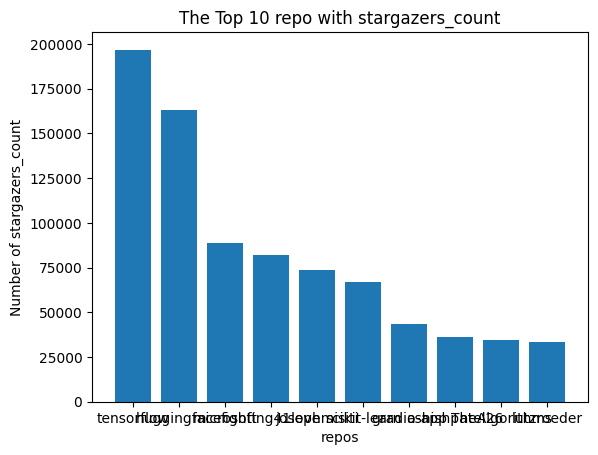

In [ ]:
#bar chart showing the top 10 repo
top_10_df=df.nlargest(10,'reserved')
plt.bar(x=top_10_df['owner_username'],height=top_10_df['reserved'])

plt.title('The Top 10 repo with stargazers_count')
plt.xlabel('repos')
plt.ylabel('Number of stargazers_count')

Text(0, 0.5, 'Number of Repositories')

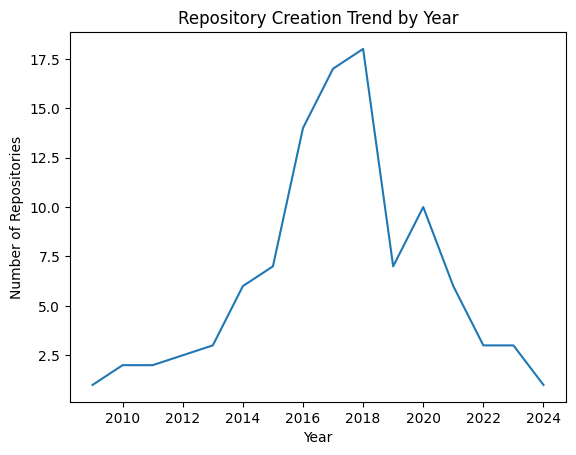

In [34]:
#show the trend of years 

#i needed to do this to calcaute the freqency of each year so i can get the index of the year and the freqency
years=df['created_at'].dt.year.value_counts().sort_index()

plt.plot(years.index,years.values)

plt.title('Repository Creation Trend by Year')
plt.xlabel('Year')
plt.ylabel('Number of Repositories')